In [7]:
from glob import glob
import pandas as pd
from nltk.tokenize import sent_tokenize
import textwrap
import random
import time
import backoff
import math
import openai
import seaborn as sns
import matplotlib.pyplot as plt

import os
from dotenv import load_dotenv

load_dotenv()
api_key_1 = os.getenv('OPENAI_API_KEY')

client = openai.OpenAI(
    api_key=api_key_1
)  

In [8]:
def print_wrapped_text(text, width=70):
    texts = text.split('\n')
    if len(texts) > 1:
        for t in texts:
            print_wrapped_text(t, width=70)
    else:
        text = texts[0]
        wrapper = textwrap.TextWrapper(width=width)
        wrapped_text = wrapper.fill(text)
        print(wrapped_text)

In [9]:
files = glob('/home/juyal/QuantifyingNarrativeSurprise/StoryScraper/stories/*.txt')
files

['/home/juyal/QuantifyingNarrativeSurprise/StoryScraper/stories/Cachildrun.txt',
 '/home/juyal/QuantifyingNarrativeSurprise/StoryScraper/stories/Honey__I_m_Home_.txt',
 '/home/juyal/QuantifyingNarrativeSurprise/StoryScraper/stories/Arachnid.txt',
 '/home/juyal/QuantifyingNarrativeSurprise/StoryScraper/stories/The_Door_in_the_Cellar.txt',
 '/home/juyal/QuantifyingNarrativeSurprise/StoryScraper/stories/The_Awardee.txt',
 '/home/juyal/QuantifyingNarrativeSurprise/StoryScraper/stories/Missing__part_2.txt',
 '/home/juyal/QuantifyingNarrativeSurprise/StoryScraper/stories/The_Time_Traveler_s_Scheme__Chapter_9___Crack.txt',
 '/home/juyal/QuantifyingNarrativeSurprise/StoryScraper/stories/Sirens_of_Lake_Station.txt',
 '/home/juyal/QuantifyingNarrativeSurprise/StoryScraper/stories/Shadow_Play.txt',
 '/home/juyal/QuantifyingNarrativeSurprise/StoryScraper/stories/Dark_Is_the_New_Light.txt',
 '/home/juyal/QuantifyingNarrativeSurprise/StoryScraper/stories/Photomic.txt',
 '/home/juyal/QuantifyingNarra

In [10]:
story_word_counts = []

for file in files:
    with open(file, mode='r', encoding='utf-8') as f:
        text = f.read()
        # crude tokenization (split on whitespace)
        words = text.split()
        word_count = len(words)
        title = os.path.basename(file).replace('.txt', '')
        story_word_counts.append((title, word_count))

# show first few results
for title, wc in story_word_counts[:10]:
    print(f"{title:50s} {wc:>6} words")

print(f"\nTotal stories: {len(story_word_counts)}")

Cachildrun                                           1994 words
Honey__I_m_Home_                                      994 words
Arachnid                                             1835 words
The_Door_in_the_Cellar                               1359 words
The_Awardee                                          1034 words
Missing__part_2                                      2497 words
The_Time_Traveler_s_Scheme__Chapter_9___Crack        1104 words
Sirens_of_Lake_Station                               1804 words
Shadow_Play                                          1168 words
Dark_Is_the_New_Light                                1559 words

Total stories: 183


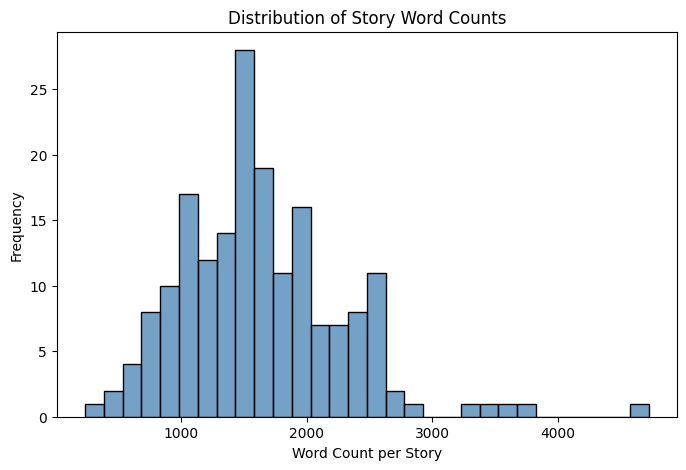

In [11]:
df = pd.DataFrame(story_word_counts, columns=["title", "word_count"])

plt.figure(figsize=(8, 5))
sns.histplot(df["word_count"], bins=30, color="steelblue")
plt.title("Distribution of Story Word Counts")
plt.xlabel("Word Count per Story")
plt.ylabel("Frequency")
plt.show()

In [12]:
def closest_sentence_index(sentence_indexes, target):
    """
    This function takes a list of numbers in ascending order (sentence_indexes) and a number (target).
    It returns the sentence_index that is closest to the target, regardless of whether it is greater or less than the target.
    """
    # Handling the case where sentence_indexes is empty
    if not sentence_indexes:
        return None

    # Initialize variables to store the closest index and its difference from target
    closest_index = sentence_indexes[0]
    min_difference = abs(target - sentence_indexes[0])

    # Iterate through the list to find the closest index
    for index in sentence_indexes:
        difference = abs(target - index)
        if difference < min_difference:
            min_difference = difference
            closest_index = index

    return closest_index

In [13]:
def sentence_indexes_within_range(sentence_indexes, target, range_val=70):
    """
    This function takes a list of numbers in ascending order (sentence_indexes), a number (target),
    and a range value (range_val). It returns a list of all sentence_indexes that are within the specified
    range of the target.
    """
    # Filter and return the indexes within the specified range of the target
    return [index for index in sentence_indexes if abs(target - index) <= range_val]

# Example usage
sentence_indexes = [-20, 200]
target = 80
sentence_indexes_within_range(sentence_indexes, target)

[]

In [14]:
def fuse_short_sentences(sentences, word_limit=5, max_len=200, split_len=160):
    """
    Merge tiny sentences into the previous one and split ultra-long sentences.
    Keeps sentence boundaries reasonable for chunking.
    """
    fused = []
    prev = ""

    for s in sentences:
        words = s.split()

        # too short -> merge into previous
        if len(words) < word_limit and fused:
            fused[-1] = fused[-1] + " " + s
            prev = fused[-1]
            continue

        # too long -> split into ~split_len word pieces
        if len(words) > max_len:
            n_parts = (len(words) // split_len) + 1
            step = len(words) // n_parts
            for i in range(n_parts):
                part = " ".join(words[i*step:(i+1)*step])
                if part.strip():
                    fused.append(part)
            # tail
            tail = " ".join(words[n_parts*step:])
            if tail.strip():
                fused.append(tail)
            prev = fused[-1]
            continue

        # normal sentence
        fused.append(s)
        prev = s

    return fused


def closest_sentence_index(sentence_indexes, target):
    """
    Return the sentence-end word index closest to 'target'.
    Assumes sentence_indexes is sorted ascending.
    """
    if not sentence_indexes:
        return None
    best = sentence_indexes[0]
    best_diff = abs(target - best)
    for idx in sentence_indexes:
        d = abs(target - idx)
        if d < best_diff:
            best, best_diff = idx, d
    return best


def sentence_indexes_within_range(sentence_indexes, target, range_val=30):
    """
    Return all sentence-end word indices within ±range_val of 'target'.
    """
    return [idx for idx in sentence_indexes if abs(target - idx) <= range_val]


def chapterize_story(inpath):
    """
    Read a short story, tokenize to sentences, tidy extremes,
    and compute cumulative word-end indices for each sentence.
    Returns:
      allsentences  : ['' (dummy), sent1, sent2, ...]
      alldivides    : [0, w_end(sent1), w_end(sent2), ...]
      chapterdivides: [(total_words, 'EOF')]
      storylen      : total word count
    """
    with open(inpath, mode='r', encoding='utf-8') as f:
        text = f.read()

    sentences = sent_tokenize(text)
    sentences = fuse_short_sentences(sentences, word_limit=5, max_len=200, split_len=160)

    allsentences = ['']
    alldivides = [0]
    ctr = 0
    for s in sentences:
        w = len(s.split())
        ctr += w
        allsentences.append(s)
        alldivides.append(ctr)

    chapterdivides = [(ctr, 'EOF')]
    storylen = ctr
    return allsentences, alldivides, chapterdivides, storylen

def get_storyruns(allsentences,
                  alldivides,
                  storylen,
                  chunk_size=300,
                  tolerance=None,
                  offsets=None,
                  rng_seed=None,
                  prefer_nearest=True):
    """
    Create 1+ passes of ~chunk_size-word chunks aligned to sentence boundaries.

    Args:
      chunk_size     : target words per chunk (200–400 is sane for short stories)
      tolerance      : ±word slack when snapping to sentence boundaries.
                       If None, uses max(10, int(0.02 * storylen)).
      offsets        : list of starting offsets (in words). None -> [0].
                       Example for light multi-pass: [0, chunk_size//3]
      rng_seed       : seed for any random choice (for reproducibility)
      prefer_nearest : if True, pick closest boundary; else random within tolerance window.

    Returns:
      bookruns  : list of passes; each pass is a list of tuples:
                  (start_sentence_idx, end_sentence_idx, chunk_len_words, boundary_type)
                  where boundary_type in {'sentence','EOF'}
      wordpoints: per pass, the chosen (word_index, boundary_type) points
    """
    if rng_seed is not None:
        random.seed(rng_seed)

    if tolerance is None:
        tolerance = max(10, int(0.02 * storylen))  # ~2% of story length, but at least 10 words

    if offsets is None:
        offsets = [0]

    bookruns = []
    wordpoints = []

    # alldivides are sentence-end positions; keep them handy
    sentence_ends = alldivides[1:]  # drop the leading 0 for convenience

    for startblock in offsets:
        # ideal boundaries marching by chunk_size (exclude 0), ensure EOF at end
        ideals = list(range(max(0, startblock) + chunk_size, storylen, chunk_size))
        ideals.append(storylen)

        # snap ideals to actual sentence ends
        chosen_points = []
        for target in ideals:
            if target == storylen:
                chosen_points.append((storylen, 'EOF'))
                continue

            candidates = sentence_indexes_within_range(sentence_ends, target, tolerance)
            if candidates:
                if prefer_nearest:
                    point = min(candidates, key=lambda x: abs(x - target))
                else:
                    point = random.choice(candidates)
            else:
                # fallback to the single closest sentence end
                point = closest_sentence_index(sentence_ends, target)
            chosen_points.append((point, 'sentence'))

        # convert word points to chunk tuples
        tuples = []
        last_point = 0
        for point, btype in chosen_points:
            # alldivides contains 0 and all sentence ends; we snapped to those,
            # so index lookups are valid.
            start_sentence = alldivides.index(last_point) + 1
            end_sentence = alldivides.index(point)
            chunk_len = point - last_point
            tuples.append((start_sentence, end_sentence, chunk_len, btype))
            last_point = point

        bookruns.append(tuples)
        wordpoints.append(chosen_points)

    return bookruns, wordpoints

def list_story_files(story_dir):
    return sorted(glob(os.path.join(story_dir, "*.txt")))

def count_words_in_file(path):
    with open(path, encoding="utf-8") as f:
        return len(f.read().split())


In [15]:
@backoff.on_exception(
    backoff.expo,
    openai.RateLimitError,
    max_time=60,  # Set a maximum wait time in seconds (adjust as needed)
    giveup=lambda e: False  # This prevents giving up on retries
)
def completions_with_backoff(**kwargs):
    global client
    try:
        return client.chat.completions.create(**kwargs)
    except openai.APIError as e:
        print(f"Error: {e}")
        raise  # Re-raise the error to trigger the retry mechanism

In [16]:
summary_system_prompt = (
    "You are summarizing short stories or story excerpts. "
    "Each summary must be a single, self-contained present-tense sentence "
    "that describes what is happening in the scene. "
    "Do not use phrases like 'in this story' or 'the passage describes'—"
    "write as though you are inside the narrative. "
    "Focus on the key action or emotion, and omit background detail. "
    "Enclose the summary in <summary> and </summary> tags."
)

prediction_system_prompt = (
    "You are predicting the next event in a short story based on what has already happened. "
    "Write one confident, present-tense sentence about what occurs next in the narrative, "
    "without hedging or speculation. "
    "Do not refer to yourself or the text; stay within the story world. "
    "Enclose the prediction in <prediction> and </prediction> tags."
)


In [17]:
summary_fewshots = [
    {
        "role": "user",
        "content": (
            "Read the short story passage below and summarize it in one "
            "present-tense sentence that captures the most important event. "
            "Avoid meta phrases like 'this story is about' or 'the passage describes'. "
            "Write as though you are inside the scene.\n\n"
            "<passage>\n"
            "The night was silent except for the drip of rain from the gutter. "
            "Mara pressed herself against the door, listening to the footsteps outside. "
            "Someone—or something—was circling the house.\n"
            "</passage>"
        ),
    },
    {
        "role": "assistant",
        "content": (
            "<summary>Mara hides in her home as an unseen figure stalks outside in the rain.</summary>"
        ),
    },
    {
        "role": "user",
        "content": (
            "Read the short story passage below and summarize it in one present-tense sentence.\n\n"
            "<passage>\n"
            "David clutched the old photograph, its corners frayed and stained with blood. "
            "He couldn’t remember taking it—but the smiling face beside him was his own.\n"
            "</passage>"
        ),
    },
    {
        "role": "assistant",
        "content": (
            "<summary>David realizes the photograph shows an alternate version of himself he cannot recall.</summary>"
        ),
    },
]

prediction_fewshots = [
    {
        "role": "user",
        "content": (
            "Based on the short story passage below, predict what happens next in one confident, present-tense sentence. "
            "Stay within the story world and avoid hedging or speculation.\n\n"
            "<passage>\n"
            "Mara hides in the darkness, clutching the kitchen knife. "
            "The footsteps stop just outside the window.\n"
            "</passage>"
        ),
    },
    {
        "role": "assistant",
        "content": (
            "<prediction>The intruder shatters the window, forcing Mara to fight for her life.</prediction>"
        ),
    },
    {
        "role": "user",
        "content": (
            "Based on the short story passage below, predict what happens next in one confident, present-tense sentence.\n\n"
            "<passage>\n"
            "The lights flickered, and the photograph in David’s hand began to fade, "
            "the other man’s face slowly vanishing.\n"
            "</passage>"
        ),
    },
    {
        "role": "assistant",
        "content": (
            "<prediction>David feels his own body begin to dissolve as the photo disappears.</prediction>"
        ),
    },
]

In [18]:
def create_prompt(sum_or_predict, passage):
    """Builds few-shot prompt for summarization or prediction of short stories."""
    if sum_or_predict == "summary":
        system_prompt = summary_system_prompt
        user1 = summary_fewshots[0]["content"]
        assistant = summary_fewshots[1]["content"]
        user2 = f"Summarize this short story passage in one sentence.\n\n<passage>\n{passage}\n</passage>"
    elif sum_or_predict == "predict":
        system_prompt = prediction_system_prompt
        user1 = prediction_fewshots[0]["content"]
        assistant = prediction_fewshots[1]["content"]
        user2 = f"Predict what happens next in one sentence.\n\n<passage>\n{passage}\n</passage>"
    else:
        raise ValueError("sum_or_predict must be 'summary' or 'predict'")

    return system_prompt, user1, assistant, user2


In [19]:
# Test prompting function for short stories
test_passage = (
    "The rain poured harder as Maria reached the edge of the forest. "
    "She turned back once, saw the cabin lights flicker, and then stepped into the dark trees."
)

# Build the prompt
system_prompt, user1, assistant, user2 = create_prompt('summary', test_passage)

# Display each component nicely
print_wrapped_text(system_prompt)
print()
print_wrapped_text(user1)
print()
print_wrapped_text(assistant)
print()
print_wrapped_text(user2)


You are summarizing short stories or story excerpts. Each summary must
be a single, self-contained present-tense sentence that describes what
is happening in the scene. Do not use phrases like 'in this story' or
'the passage describes'—write as though you are inside the narrative.
Focus on the key action or emotion, and omit background detail.
Enclose the summary in <summary> and </summary> tags.

Read the short story passage below and summarize it in one present-
tense sentence that captures the most important event. Avoid meta
phrases like 'this story is about' or 'the passage describes'. Write
as though you are inside the scene.

<passage>
The night was silent except for the drip of rain from the gutter. Mara
pressed herself against the door, listening to the footsteps outside.
Someone—or something—was circling the house.
</passage>

<summary>Mara hides in her home as an unseen figure stalks outside in
the rain.</summary>

Summarize this short story passage in one sentence.

<passag

In [20]:
def submit_prompt(system_prompt, user1, assistant, user2):
    """
    Assemble and send a complete prompt sequence to the OpenAI API.
    For short-story summarization or prediction — no recap handling needed.
    """
    prompt = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user1},
        {"role": "assistant", "content": assistant},
        {"role": "user", "content": user2}
    ]

    try:
        completion = completions_with_backoff(
            model="gpt-4o-mini",                # or "gpt-4o" for higher quality
            messages=prompt,
            max_completion_tokens=400,          # new parameter name (not max_tokens)
        )
        return completion

    except Exception as e:
        print(f"[Error in submit_prompt] {e}")
        return None

In [21]:
import re

def parse_summary(text):
    """
    Extracts and cleans the summary content from a model reply.
    Handles cases with stray spaces, capitalization, or missing tags.
    """
    if not text:
        return ""
    
    # Try to extract content between tags if they exist
    match = re.search(r"<\s*summary\s*>(.*?)<\s*/\s*summary\s*>", text, re.IGNORECASE | re.DOTALL)
    if match:
        cleaned = match.group(1).strip()
    else:
        # Fallback: remove any accidental tags and trim
        cleaned = re.sub(r"<.*?>", "", text).strip()
    return cleaned


def parse_prediction(text):
    """
    Extracts and cleans the prediction content from a model reply.
    Handles minor tag errors and extra spaces.
    """
    if not text:
        return ""
    
    match = re.search(r"<\s*prediction\s*>(.*?)<\s*/\s*prediction\s*>", text, re.IGNORECASE | re.DOTALL)
    if match:
        cleaned = match.group(1).strip()
    else:
        cleaned = re.sub(r"<.*?>", "", text).strip()
    return cleaned


In [22]:
def condense_summary(thesummary):
    """
    Uses the model to condense a repetitive or lengthy plot summary
    into a concise 3–5 sentence paragraph that preserves core events
    and main characters.
    """
    if not thesummary or not thesummary.strip():
        return ""

    prompt = [
        {
            "role": "system",
            "content": (
                "You are condensing plot summaries of short stories. "
                "The input may contain repetition or excessive detail. "
                "Infer the broad outline of the story and express it "
                "as a cohesive paragraph of about four sentences. "
                "Avoid redundant phrasing, focus on key characters and events."
            )
        },
        {
            "role": "user",
            "content": (
                "Condense the following story summary into one cohesive paragraph. "
                "Keep essential plot elements, but remove minor or repetitive details:\n\n"
                f"{thesummary.strip()}"
            )
        }
    ]

    try:
        completion = completions_with_backoff(
            model="gpt-5-nano",             
            messages=prompt,
            max_completion_tokens=300,
        )
        return completion.choices[0].message.content.strip()

    except Exception as e:
        print(f"[Error in condense_summary] {e}")
        return ""


In [23]:
def get_recap(recap_list):
    """Join list of recap sentences into a single string and return word length."""
    recap_text = ' '.join(recap_list).strip()
    recap_len = len(recap_text.split())
    return recap_text, recap_len


def make_recap(recent_recaps, long_range_recaps):
    """
    Condense running recaps if they get too long.
    This keeps the memory summary concise for short-story workflows.
    """
    recent_recap_text, recent_len = get_recap(recent_recaps)

    # Condense recent recaps if too long
    if recent_len > 300:
        condensed = condense_summary(recent_recap_text)
        long_range_recaps.append(condensed)
        print(f"[Recap] Condensed recent recaps from {recent_len} → {len(condensed.split())} words.")
        recent_recaps = []

    long_range_text, long_range_len = get_recap(long_range_recaps)

    # Condense long-range recaps if too long
    if long_range_len > 500:
        condensed = condense_summary(long_range_text)
        long_range_recaps = [condensed]
        long_range_text = condensed
        print(f"[Recap] Condensed long-range recaps from {long_range_len} → {len(condensed.split())} words.")

    full_recap_text = (long_range_text + " " + recent_recap_text).strip()
    full_recap_len = len(full_recap_text.split())

    return full_recap_text, full_recap_len, recent_recaps, long_range_recaps


def process_story(filepath):
    """
    Core short-story processing pipeline.
    - Tokenizes story into sentences
    - Builds prompts for summary + prediction
    - Calls API and saves results as a TSV
    """
    outfilename = filepath.split('/')[-1].replace('.txt', '.tsv')
    allsentences, alldivides, chapterdivides, storylen = chapterize_story(filepath)

    rows = []
    recent_recaps = []
    long_range_recaps = []

    totalctr = 0

    # Iterate sentence by sentence (or chunk by chunk if you like)
    for idx, sentence in enumerate(allsentences[1:], start=1):
        passage_text = sentence.replace('\n', ' ').strip()
        totalctr += len(passage_text.split())
        position = totalctr / storylen

        # Generate recap for continuity (if ever needed)
        full_recap_text, full_recap_len, recent_recaps, long_range_recaps = make_recap(
            recent_recaps, long_range_recaps
        )

        # Build summary prompt
        system_prompt, user1, assistant, user2 = create_prompt('summary', passage_text)
        completion = submit_prompt(system_prompt, user1, assistant, user2)
        answer = completion.choices[0].message.content if completion else ""
        summary = parse_summary(answer)

        # Build prediction prompt
        system_prompt, user1, assistant, user2 = create_prompt('predict', passage_text)
        completion = submit_prompt(system_prompt, user1, assistant, user2)
        answer = completion.choices[0].message.content if completion else ""
        prediction = parse_prediction(answer)

        # Append rows
        rows.append({
            "filename": filepath,
            "title": title,
            "mode": "summary",
            "text": summary,
            "position": round(position, 5),
            "sentence_index": idx,
            "recap_length": full_recap_len,
            "passage_length": len(passage_text.split()),
        })
        recent_recaps.append(summary)

        rows.append({
            "filename": filepath,
            "title": title,
            "mode": "prediction",
            "text": prediction,
            "position": round(position, 5),
            "sentence_index": idx,
            "recap_length": full_recap_len,
            "passage_length": len(passage_text.split()),
        })

        if idx % 3 == 0:
            print(f"[{idx}] Summary: {summary}")
            print(f"     Prediction: {prediction}\n")

    # Save to file
    outdf = pd.DataFrame(rows)
    outdir = "/home/juyal/QuantifyingNarrativeSurprise/StoryScraper/story_outputs"
    os.makedirs(outdir, exist_ok=True)
    outpath = f"{outdir}/{outfilename}"
    outdf.to_csv(outpath, sep='\t', index=False)
    print(f"\n✅ Saved results to {outpath}\n")


In [24]:
files[0]

'/home/juyal/QuantifyingNarrativeSurprise/StoryScraper/stories/Cachildrun.txt'

In [96]:
from pathlib import Path

# Define file path
output_path = Path("/home/juyal/QuantifyingNarrativeSurprise/StoryScraper/stories/BaselineStory.txt")

# The generic story text
baseline_story = """Once upon a time, there was a hare who was very proud of how fast he could run. He would laugh at the slow movements of the tortoise and boast to all the other animals about his speed. “I could beat you in a race any day,” he told the tortoise. The tortoise, tired of the hare’s arrogance, quietly replied, “Then let’s race and find out who is faster.” The hare laughed so hard that tears came to his eyes, but he agreed to the race, thinking it would be easy entertainment.

The next morning, all the animals gathered to watch. The fox marked the start and the finish line. As soon as the race began, the hare leapt forward and quickly left the tortoise far behind. After running for a while, the hare looked back and could not even see the tortoise on the trail. He laughed and decided there was no need to rush. Confident of his victory, he found a soft patch of grass under a tree and decided to take a nap.

Meanwhile, the tortoise kept walking. Step by step, he moved slowly but steadily, never stopping to rest. Hours passed. The sun rose high in the sky, and still the tortoise moved forward, one deliberate foot after another. When the hare finally woke up, the sun was already beginning to set. He yawned, stretched, and began to run again, expecting to see the tortoise far behind him. But to his surprise, the tortoise was only a few steps from the finish line. The hare sprinted as fast as he could, but it was too late. The tortoise crossed the finish line first, to the cheers of all the animals.

The hare hung his head low in shame while the tortoise smiled modestly and said, “Slow and steady wins the race.” The hare never bragged about his speed again. From that day on, all the animals remembered that overconfidence and laziness can make even the fastest lose to the most patient and persistent.
"""

# Write to file
output_path.write_text(baseline_story, encoding='utf-8')

output_path


PosixPath('/home/juyal/QuantifyingNarrativeSurprise/StoryScraper/stories/BaselineStory.txt')

In [25]:
process_story(
    filepath="/home/juyal/QuantifyingNarrativeSurprise/StoryScraper/stories/Cachildrun.txt",
)

[3] Summary: The puppies eagerly bark as they anticipate their meal.
     Prediction: The owner walks in with a bowl of kibble, delighting the eager puppies as they wag their tails in excitement.

[6] Summary: The selection of pets is limited compared to that of the larger pet chains.
     Prediction: The small pet store owner decides to reach out to local breeders to expand their selection.

[9] Summary: Despite the abundance of cats and dogs at shelters, only rare breeds attract buyers.
     Prediction: The shelter decides to showcase the rare breeds in a special adoption event to attract potential owners.

[12] Summary: Jorge observes an unfamiliar strange animal sitting nearby.
     Prediction: The strange animal suddenly turns its head, revealing vibrant, glowing eyes that lock onto Jorge's gaze.

[15] Summary: He uncovers a small animal, no larger than a kitten, from beneath the lid.
     Prediction: The creature lets out a soft, plaintive cry as it snuggles against his hand, its

In [97]:
process_story(
    filepath="/home/juyal/QuantifyingNarrativeSurprise/StoryScraper/stories/BaselineStory.txt",
)

[3] Summary: Confident in his speed, he challenges the tortoise to a race.
     Prediction: The tortoise calmly replies, “Then let’s race and find out.”

[6] Summary: The fox establishes both the beginning and end of a race.
     Prediction: The other animals gather around, excitement buzzing in the air as they prepare for the race to begin.

[9] Summary: He chuckles and chooses to take his time.
     Prediction: He leans back in his chair, savoring the moment as he slowly sips his drink.

[12] Summary: He perseveres forward slowly and steadily, refusing to pause for rest as hours slip by.
     Prediction: Finally, he reaches the summit, looking out over the vast landscape that stretches endlessly before him.

[15] Summary: He yawns and stretches before resuming his run, confident that the tortoise lags far behind.
     Prediction: To his surprise, he glances back and finds the tortoise steadily gaining ground, unyielding in its slow yet continuous progress.

[18] Summary: The tortoise

In [26]:
# --- Required Imports ---
import pandas as pd
from sentence_transformers import SentenceTransformer, util
from transformers import pipeline
from tqdm import tqdm
import matplotlib.pyplot as plt

In [86]:
# --- 1. Load and prepare data ---
path = "/home/juyal/QuantifyingNarrativeSurprise/outputs/Cachildrun.tsv"
df = pd.read_csv(path, sep='\t')

# Keep only summary/prediction rows, ordered by story progression
df = df.sort_values(by="position").reset_index(drop=True)

# Build pairs: each prediction's "actual" = next summary
pairs = []
for i in range(len(df) - 1):
    if df.loc[i, "mode"] == "prediction" and df.loc[i + 1, "mode"] == "summary":
        pairs.append({
            "prediction": df.loc[i, "text"],
            "actual": df.loc[i + 1, "text"],
            "position": df.loc[i, "position"],
            "title": df.loc[i, "title"]
        })

pairs_df = pd.DataFrame(pairs)
print(f"Prepared {len(pairs_df)} prediction→actual pairs.")
pairs_df.head(3)


Prepared 112 prediction→actual pairs.


,prediction,actual,position,title
0,"As the doorbell jingles, the first customers w...",He hurriedly feeds the animals at Valparaiso P...,0.01805,Dark_Is_the_New_Light
1,"A bowl of kibble is placed on the floor, and t...",The puppies eagerly bark as they await their m...,0.02357,Dark_Is_the_New_Light
2,He pours the dog food into the massive storage...,He finishes sealing the snake casings and then...,0.03310,Dark_Is_the_New_Light


In [98]:
# --- 1. Load and prepare data ---
import pandas as pd

path = "/home/juyal/QuantifyingNarrativeSurprise/StoryScraper/story_outputs/BaselineStory.tsv"
df_base = pd.read_csv(path, sep='\t')

# Keep only summary/prediction rows, ordered by story progression
df_base = df_base.sort_values(by="position").reset_index(drop=True)

# Build pairs: each prediction's "actual" = next summary
pairs = []
for i in range(len(df_base) - 1):
    if (
        df_base.loc[i, "mode"] == "prediction"
        and df_base.loc[i + 1, "mode"] == "summary"
    ):
        pairs.append({
            "prediction": df_base.loc[i, "text"],
            "actual": df_base.loc[i + 1, "text"],
            "position": df_base.loc[i, "position"],
            "title": df_base.loc[i, "title"]
        })

pairs_df_base = pd.DataFrame(pairs)
print(f"✅ Prepared {len(pairs_df_base)} prediction→actual pairs.")
pairs_df_base.head(3)


✅ Prepared 19 prediction→actual pairs.


,prediction,actual,position,title
0,"The hare challenges a tortoise to a race, conf...",He mocks the tortoise's sluggishness while bra...,0.05341,Dark_Is_the_New_Light
1,"The tortoise, unfazed by the boastful hare, ch...","Confident in his speed, he challenges the tort...",0.11276,Dark_Is_the_New_Light
2,"The tortoise calmly replies, “Then let’s race ...",The tortoise challenges the overconfident hare...,0.15134,Dark_Is_the_New_Light


In [28]:
emb_model = SentenceTransformer('all-mpnet-base-v2')
nli_model = pipeline("text-classification", model="roberta-large-mnli", truncation=True)

results = []

for _, row in tqdm(pairs_df.iterrows(), total=len(pairs_df), desc="Scoring story"):
    pred, actual = row['prediction'].strip(), row['actual'].strip()

    # Cosine similarity (semantic closeness)
    emb_pred = emb_model.encode(pred, convert_to_tensor=True)
    emb_actual = emb_model.encode(actual, convert_to_tensor=True)
    cos_sim = util.cos_sim(emb_pred, emb_actual).item()
    semantic_diff = 1 - cos_sim

    # NLI (logical relationship)
    # NLI (logical relationship)
    nli_result = nli_model({"text": pred, "text_pair": actual}, truncation=True)

    # Some versions return a list, others return a single dict
    if isinstance(nli_result, list):
        nli_out = nli_result[0].get('label', 'UNKNOWN')
    else:
        nli_out = nli_result.get('label', 'UNKNOWN')

    results.append({
        "semantic_sim": round(cos_sim, 4),
        "semantic_diff": round(semantic_diff, 4),
        "nli_label": nli_out
    })

scores_df = pd.concat([pairs_df.reset_index(drop=True), pd.DataFrame(results)], axis=1)
scores_df.to_csv("/home/juyal/QuantifyingNarrativeSurprise/outputs/Cachildrun_analysis.csv", index=False)

scores_df.head(10)

Some weights of the model checkpoint at roberta-large-mnli were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu
Scoring story: 100%|██████████| 112/112 [00:40<00:00,  2.74it/s]


,prediction,actual,position,title,semantic_sim,semantic_diff,nli_label
0,"As the doorbell jingles, the first customers w...",He hurriedly feeds the animals at Valparaiso P...,0.01805,Dark_Is_the_New_Light,0.5947,0.4053,NEUTRAL
1,"A bowl of kibble is placed on the floor, and t...",The puppies eagerly bark as they await their m...,0.02357,Dark_Is_the_New_Light,0.7206,0.2794,NEUTRAL
2,He pours the dog food into the massive storage...,He finishes sealing the snake casings and then...,0.03310,Dark_Is_the_New_Light,0.6798,0.3202,NEUTRAL
3,The small pet store owner decides to expand th...,The local pet store lacks the wide selection o...,0.04112,Dark_Is_the_New_Light,0.5673,0.4327,NEUTRAL
4,"As new businesses emerge in the area, they scr...",They flourish in a time without competition.,0.04614,Dark_Is_the_New_Light,0.1538,0.8462,CONTRADICTION
5,"The group exchanges relieved glances, knowing ...",Despite the abundance of cats and dogs at shel...,0.04915,Dark_Is_the_New_Light,-0.0340,1.0340,NEUTRAL
6,A sudden influx of rare breed puppies and kitt...,Alberto calls out to Jorge to inform him that ...,0.05918,Dark_Is_the_New_Light,0.1090,0.8910,NEUTRAL
7,Jorge rushes outside to greet the delivery dri...,The delivery driver arrives with a cart carryi...,0.06419,Dark_Is_the_New_Light,0.5061,0.4939,NEUTRAL
8,"Curiosity overcomes him, and Jorge approaches ...",Jorge notices an unfamiliar and strange animal...,0.08024,Dark_Is_the_New_Light,0.7401,0.2599,NEUTRAL
9,"As Alberto eagerly peers into the cage, the ex...",His dad sets a cage on the counter next to the...,0.08927,Dark_Is_the_New_Light,0.4973,0.5027,CONTRADICTION


In [99]:
from sentence_transformers import SentenceTransformer, util
from transformers import pipeline
from tqdm import tqdm
import pandas as pd
import numpy as np

# --- Load models ---
emb_model = SentenceTransformer('all-mpnet-base-v2')
nli_model = pipeline("text-classification", model="roberta-large-mnli", truncation=True)

# --- Initialize results list ---
results = []

# --- Iterate through prediction→actual pairs ---
for _, row in tqdm(pairs_df_base.iterrows(), total=len(pairs_df_base), desc="Scoring Baseline Story"):
    pred = str(row.get('prediction', '')).strip()
    actual = str(row.get('actual', '')).strip()

    # Skip empty or invalid pairs
    if not pred or not actual or pred.lower() == 'nan' or actual.lower() == 'nan':
        continue

    # Compute cosine similarity (semantic closeness)
    emb_pred = emb_model.encode(pred, convert_to_tensor=True)
    emb_actual = emb_model.encode(actual, convert_to_tensor=True)
    cos_sim = util.cos_sim(emb_pred, emb_actual).item()
    semantic_diff = 1 - cos_sim

    # Compute NLI (logical relationship)
    try:
        nli_result = nli_model({"text": pred, "text_pair": actual}, truncation=True)
        if isinstance(nli_result, list):
            nli_out = nli_result[0].get('label', 'UNKNOWN')
        else:
            nli_out = nli_result.get('label', 'UNKNOWN')
    except Exception as e:
        print(f"⚠️ NLI error at row {_}: {e}")
        nli_out = 'ERROR'

    results.append({
        "semantic_sim": round(cos_sim, 4),
        "semantic_diff": round(semantic_diff, 4),
        "nli_label": nli_out
    })

# --- Merge results into DataFrame ---
scores_df_base = pd.concat([pairs_df_base.reset_index(drop=True).iloc[:len(results)], pd.DataFrame(results)], axis=1)

# --- Save output ---
scores_df_base.to_csv("/home/juyal/QuantifyingNarrativeSurprise/outputs/BaselineStory_analysis.csv", index=False)

print(f"✅ Analysis complete for {len(scores_df_base)} valid pairs.")
scores_df_base.head(10)


Some weights of the model checkpoint at roberta-large-mnli were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu
Scoring Baseline Story: 100%|██████████| 19/19 [00:06<00:00,  2.89it/s]

✅ Analysis complete for 19 valid pairs.


,prediction,actual,position,title,semantic_sim,semantic_diff,nli_label
0,"The hare challenges a tortoise to a race, conf...",He mocks the tortoise's sluggishness while bra...,0.05341,Dark_Is_the_New_Light,0.4713,0.5287,NEUTRAL
1,"The tortoise, unfazed by the boastful hare, ch...","Confident in his speed, he challenges the tort...",0.11276,Dark_Is_the_New_Light,0.8516,0.1484,CONTRADICTION
2,"The tortoise calmly replies, “Then let’s race ...",The tortoise challenges the overconfident hare...,0.15134,Dark_Is_the_New_Light,0.6041,0.3959,NEUTRAL
3,"The race begins with the hare sprinting ahead,...",The animals congregate the following morning i...,0.27300,Dark_Is_the_New_Light,0.2586,0.7414,NEUTRAL
4,"The wise old owl begins to speak, announcing t...",The fox establishes both the beginning and end...,0.29970,Dark_Is_the_New_Light,0.2831,0.7169,CONTRADICTION
5,"The other animals gather around, excitement bu...",The hare dashes ahead at the start of the race...,0.32641,Dark_Is_the_New_Light,0.4284,0.5716,NEUTRAL
6,"The hare, confident in its lead, decides to ta...",The hare glances back during the race and real...,0.37685,Dark_Is_the_New_Light,0.3961,0.6039,NEUTRAL
7,"The hare, confident in his lead, decides to li...",He chuckles and chooses to take his time.,0.43323,Dark_Is_the_New_Light,0.2296,0.7704,CONTRADICTION
8,"He leans back in his chair, savoring the momen...","Feeling sure of his success, he settles down o...",0.46291,Dark_Is_the_New_Light,0.4118,0.5882,CONTRADICTION
9,"As he drifts off to sleep, a sudden rustling i...",The tortoise continues to move forward steadil...,0.52226,Dark_Is_the_New_Light,0.1095,0.8905,CONTRADICTION


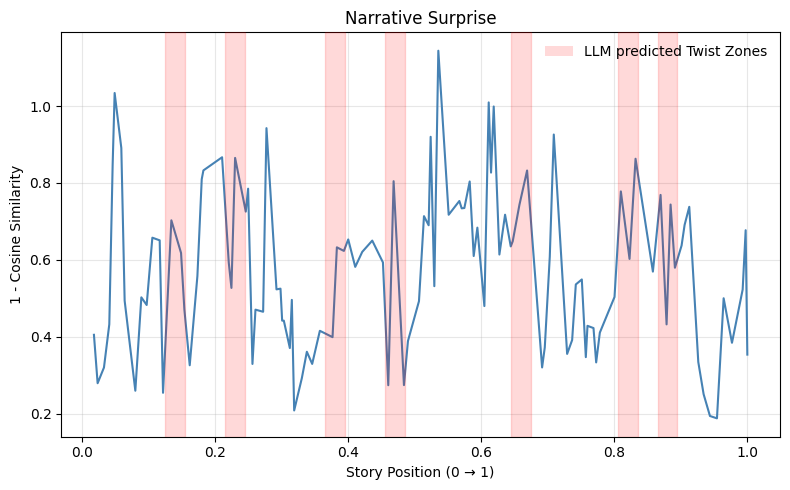

In [93]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Define twist marker positions
markers = [0.14, 0.23, 0.38, 0.47, 0.66, 0.82, 0.88]

plt.figure(figsize=(8, 5))

# Plot the main surprise curve
plt.plot(
    scores_df['position'],
    scores_df['semantic_diff'],
    color='steelblue',
    linewidth=1.5,
    label='Surprise (1 - Cosine Sim)'
)

# Overlay translucent red bands for twist regions
band_width = 0.03  # width of each shaded region
for m in markers:
    plt.axvspan(
        m - band_width / 2,
        m + band_width / 2,
        color='red',
        alpha=0.15,
        zorder=5
    )

# Create a proxy patch for legend
twist_patch = Patch(facecolor='red', alpha=0.15, label='LLM predicted Twist Zones')

# Labels and style
plt.title("Narrative Surprise")
plt.xlabel("Story Position (0 → 1)")
plt.ylabel("1 - Cosine Similarity")
plt.grid(True, alpha=0.3)
plt.legend(handles=[twist_patch], frameon=False, loc='upper right')
plt.tight_layout()
plt.show()


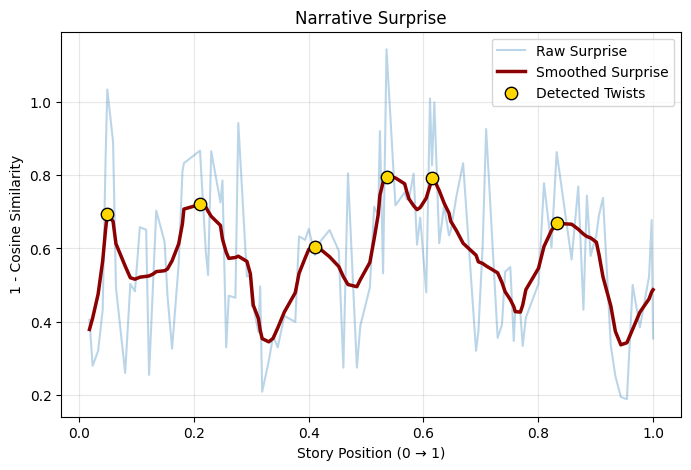

Twist at position 0.05: The group exchanges relieved glances, knowing that their close call only strengthens their...
Twist at position 0.21: The group bursts into laughter as they decorate the main display with the bizarre artwork,...
Twist at position 0.41: The cat pounces on the empty space, confused by the sudden disappearance of its prey....
Twist at position 0.54: The team celebrates their success, knowing their hard work has finally paid off....
Twist at position 0.61: The voice grows louder, demanding answers as tension fills the air....
Twist at position 0.83: The creature lunges toward the observer, its eyes gleaming with a predatory hunger....


In [83]:
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

# Smooth the surprise curve
smooth = gaussian_filter1d(scores_df['semantic_diff'], sigma=2)

# Detect local peaks (potential twists)
peaks, _ = find_peaks(smooth, prominence=0.05)  # tweak prominence for sensitivity

# Plot everything
plt.figure(figsize=(8,5))
plt.plot(scores_df['position'], scores_df['semantic_diff'], alpha=0.3, label="Raw Surprise")
plt.plot(scores_df['position'], smooth, color='darkred', linewidth=2.5, label="Smoothed Surprise")

# Highlight twist points
plt.scatter(scores_df['position'].iloc[peaks],
            smooth[peaks],
            color='gold', s=80, edgecolor='black', zorder=5, label="Detected Twists")

plt.title("Narrative Surprise")
plt.xlabel("Story Position (0 → 1)")
plt.ylabel("1 - Cosine Similarity")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Print twist points with context
for idx in peaks:
    pos = scores_df['position'].iloc[idx]
    pred = scores_df['prediction'].iloc[idx]
    print(f"Twist at position {pos:.2f}: {pred[:90]}...")


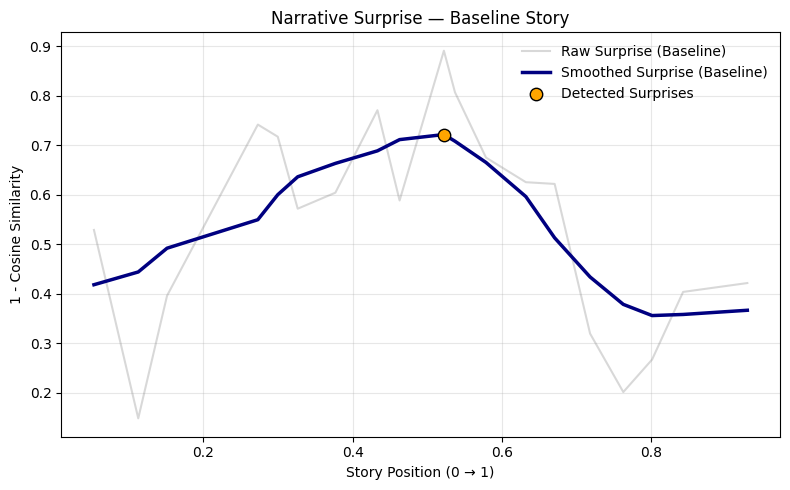


Detected narrative surprises in baseline story:

Surprise at position 0.52: As he drifts off to sleep, a sudden rustling in the bushes stirs him, signaling an unexpec...


In [100]:
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

# --- Smooth the surprise curve for baseline ---
smooth_base = gaussian_filter1d(scores_df_base['semantic_diff'], sigma=2)

# --- Detect local peaks (potential “twists” or shifts in coherence) ---
peaks_base, _ = find_peaks(smooth_base, prominence=0.05)  # adjust prominence as needed

# --- Plot the curve ---
plt.figure(figsize=(8, 5))
plt.plot(scores_df_base['position'], scores_df_base['semantic_diff'],
         alpha=0.3, color='gray', label="Raw Surprise (Baseline)")
plt.plot(scores_df_base['position'], smooth_base,
         color='navy', linewidth=2.5, label="Smoothed Surprise (Baseline)")

# --- Highlight detected peaks ---
plt.scatter(scores_df_base['position'].iloc[peaks_base],
            smooth_base[peaks_base],
            color='orange', s=80, edgecolor='black', zorder=5, label="Detected Surprises")

plt.title("Narrative Surprise — Baseline Story")
plt.xlabel("Story Position (0 → 1)")
plt.ylabel("1 - Cosine Similarity")
plt.grid(True, alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# --- Print the key peaks with context ---
print("\nDetected narrative surprises in baseline story:\n")
for idx in peaks_base:
    pos = scores_df_base['position'].iloc[idx]
    pred = scores_df_base['prediction'].iloc[idx]
    print(f"Surprise at position {pos:.2f}: {pred[:90]}...")


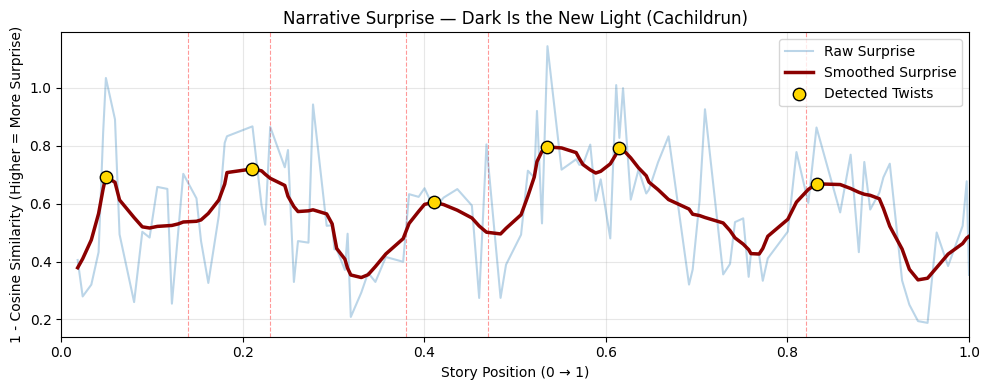

Twist at position 0.05: The group exchanges relieved glances, knowing that their close call only strengthens their...
Twist at position 0.21: The group bursts into laughter as they decorate the main display with the bizarre artwork,...
Twist at position 0.41: The cat pounces on the empty space, confused by the sudden disappearance of its prey....
Twist at position 0.54: The team celebrates their success, knowing their hard work has finally paid off....
Twist at position 0.61: The voice grows louder, demanding answers as tension fills the air....
Twist at position 0.83: The creature lunges toward the observer, its eyes gleaming with a predatory hunger....


In [ ]:
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

# Smooth the surprise curve
smooth = gaussian_filter1d(scores_df['semantic_diff'], sigma=2)

# Detect local peaks (potential twists)
peaks, _ = find_peaks(smooth, prominence=0.05)  # tweak prominence for sensitivity



# Plot everything
plt.figure(figsize=(10, 4))
plt.plot(scores_df['position'], scores_df['semantic_diff'], alpha=0.3, label="Raw Surprise")
plt.plot(scores_df['position'], smooth, color='darkred', linewidth=2.5, label="Smoothed Surprise")

# Highlight twist points
plt.scatter(scores_df['position'].iloc[peaks],
            smooth[peaks],
            color='gold', s=80, edgecolor='black', zorder=5, label="Detected Twists")

# Add vertical marker lines
for m in markers:
    plt.axvline(x=m, color='red', linestyle='--', linewidth=0.8, alpha=0.4, zorder=0)

plt.title("Narrative Surprise — Dark Is the New Light (Cachildrun)")
plt.xlabel("Story Position (0 → 1)")
plt.ylabel("1 - Cosine Similarity (Higher = More Surprise)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

# Print twist points with context
for idx in peaks:
    pos = scores_df['position'].iloc[idx]
    pred = scores_df['prediction'].iloc[idx]
    print(f"Twist at position {pos:.2f}: {pred[:90]}...")


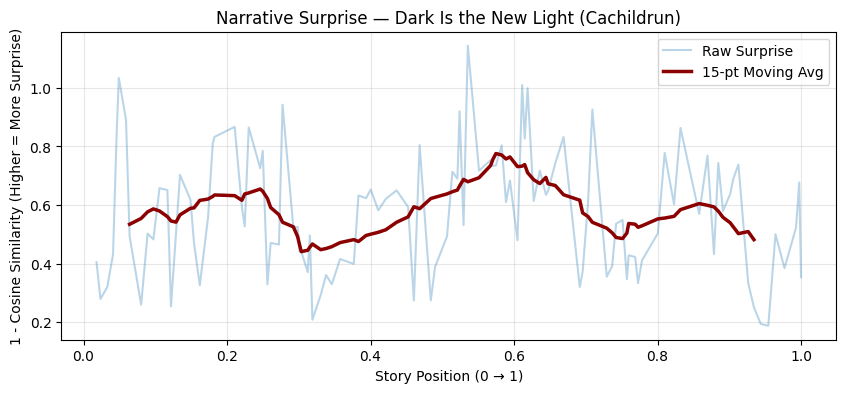

In [31]:
window = 15  # increase for smoother trend
scores_df['smooth_diff'] = scores_df['semantic_diff'].rolling(window=window, center=True).mean()

plt.figure(figsize=(10,4))
plt.plot(scores_df['position'], scores_df['semantic_diff'], alpha=0.3, label="Raw Surprise")
plt.plot(scores_df['position'], scores_df['smooth_diff'], linewidth=2.5, color='darkred', label=f"{window}-pt Moving Avg")
plt.title("Narrative Surprise — Dark Is the New Light (Cachildrun)")
plt.xlabel("Story Position (0 → 1)")
plt.ylabel("1 - Cosine Similarity (Higher = More Surprise)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [36]:
import numpy as np
import pandas as pd
from scipy.signal import find_peaks

def detect_peaks_story(df, z_thr=2.0, min_dist=2, min_prom=0.15):
    """
    Detect peaks in the semantic_diff curve, marking moments where the
    model’s prediction diverges sharply from the actual next sentence.
    Works directly on story-level data (position, semantic_diff, etc.).
    """
    # Extract the signal
    x = df['semantic_diff'].to_numpy()
    mu, sigma = np.mean(x), np.std(x) if np.std(x) > 1e-12 else 1.0
    z = (x - mu) / sigma

    # Detect peaks
    peaks, props = find_peaks(x, distance=min_dist, prominence=min_prom)

    # Filter by z-score threshold
    filtered_peaks = [i for i in peaks if z[i] > z_thr]

    if not filtered_peaks:
        print("No peaks detected — try lowering z_thr or min_prom.")
        return pd.DataFrame()

    # Gather peak data
    out = df.iloc[filtered_peaks].copy()
    out['z_score'] = z[filtered_peaks]
    out['prominence'] = props['prominences'][:len(filtered_peaks)]
    return out.reset_index(drop=True)


In [41]:
peaks_df = detect_peaks_story(scores_df)
peaks_df


,prediction,actual,position,title,semantic_sim,semantic_diff,nli_label,smooth_diff,z_score,prominence
0,"The group exchanges relieved glances, knowing ...",Despite the abundance of cats and dogs at shel...,0.04915,Dark_Is_the_New_Light,-0.0340,1.0340,NEUTRAL,NaN,2.231061,0.7546
1,"The team celebrates their success, knowing the...",The father coldly insists on sacrificing a pup...,0.53561,Dark_Is_the_New_Light,-0.1439,1.1439,CONTRADICTION,0.679567,2.762818,0.3979
2,"He reaches into the cage, and they instinctive...",The speaker vehemently denies any involvement ...,0.61133,Dark_Is_the_New_Light,-0.0095,1.0095,CONTRADICTION,0.732913,2.112516,0.3768
3,"The group exchanges shocked glances, unsure of...",His dad enters the shop carrying a dachshund.,0.61886,Dark_Is_the_New_Light,0.0011,0.9989,CONTRADICTION,0.710613,2.061228,0.5374


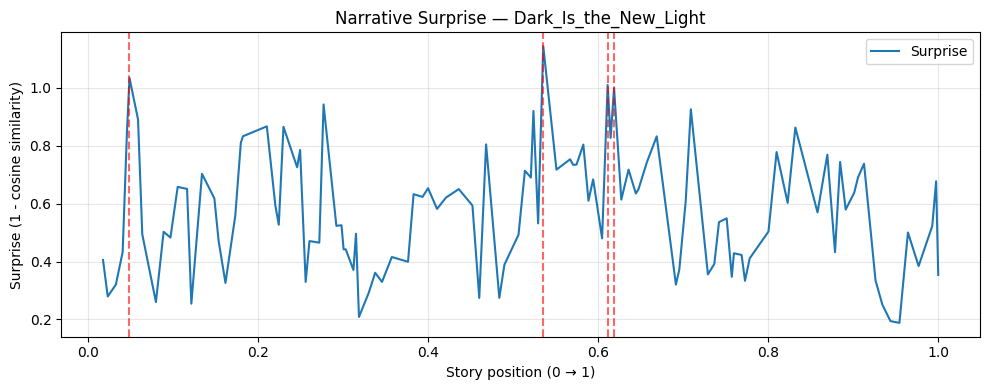

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(scores_df['position'], scores_df['semantic_diff'], linewidth=1.5, label="Surprise")

for _, row in peaks_df.iterrows():
    plt.axvline(row['position'], color='red', linestyle='--', alpha=0.6)

plt.title(f"Narrative Surprise — {scores_df['title'].iloc[0]}")
plt.xlabel("Story position (0 → 1)")
plt.ylabel("Surprise (1 - cosine similarity)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


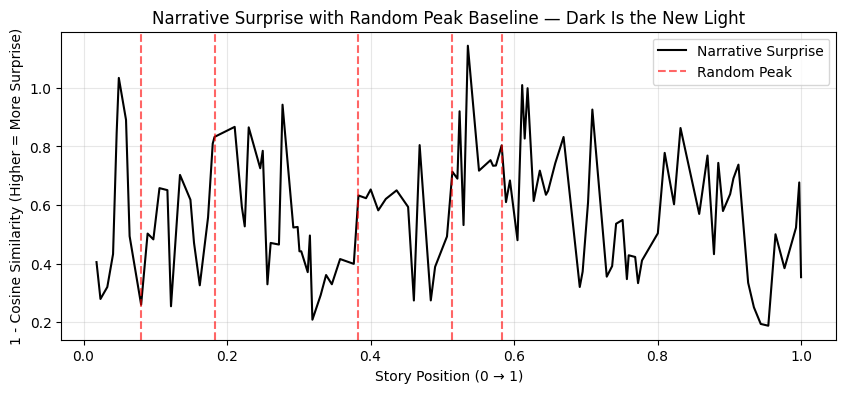

In [51]:
import numpy as np
import matplotlib.pyplot as plt

def uniform_random_peaks(N, k, min_dist=3, seed=42):
    """Uniform random baseline peaks, count-matched with min spacing."""
    rng = np.random.default_rng(seed)
    cand = np.sort(rng.choice(N, size=min(N, k*3), replace=False))
    keep = []
    last = -1e9
    for i in cand:
        if i - last >= min_dist:
            keep.append(i)
            last = i
        if len(keep) >= k:
            break
    return np.array(keep, dtype=int)

# --- Load your data (already has `semantic_diff` and `position`)
scores_df = scores_df.sort_values("position").reset_index(drop=True)
N = len(scores_df)
k = 5  # or len(model_peaks) if you have them

# Generate baseline
rand_peaks = uniform_random_peaks(N, k, min_dist=3)

# Plot
plt.figure(figsize=(10,4))
plt.plot(scores_df["position"], scores_df["semantic_diff"], label="Narrative Surprise", color="black")

# Overlay baseline vertical lines
for p in rand_peaks:
    plt.axvline(scores_df.loc[p, "position"], color="red", linestyle="--", alpha=0.6, label="Random Peak" if p == rand_peaks[0] else "")

plt.title("Narrative Surprise with Random Peak Baseline — Dark Is the New Light")
plt.xlabel("Story Position (0 → 1)")
plt.ylabel("1 - Cosine Similarity (Higher = More Surprise)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [53]:
import pandas as pd

# Load your existing coherence dataframe
scores_df = pd.read_csv("/home/juyal/QuantifyingNarrativeSurprise/outputs/Cachildrun_analysis.csv")

# --- Compute per-story summary metrics ---
story_summary = (
    scores_df.groupby('title', as_index=False)
             .agg(
                 mean_cos=('semantic_sim', 'mean'),       # average similarity
                 mean_diff=('semantic_diff', 'mean'),     # average difference (1 - cosine)
                 std_diff=('semantic_diff', 'std'),       # variability of difference
                 entailment=('nli_label', lambda x: (x == 'ENTAILMENT').mean()),
                 contradiction=('nli_label', lambda x: (x == 'CONTRADICTION').mean()),
                 neutral=('nli_label', lambda x: (x == 'NEUTRAL').mean())
             )
)

# --- Compute surprise and coherence metrics ---
story_summary['surprise_score'] = 1 - story_summary['mean_cos']
story_summary['nli_surprise'] = (
    story_summary['contradiction'] + 0.5 * story_summary['neutral']
)
story_summary['combined_surprise'] = (
    0.7 * story_summary['surprise_score'] + 0.3 * story_summary['nli_surprise']
)

# --- Save the per-story metrics ---
outpath = "/home/juyal/QuantifyingNarrativeSurprise/outputs/story_level_summary.csv"
story_summary.to_csv(outpath, index=False)

print(f"Story-level coherence metrics saved to {outpath}")
display(story_summary)


Story-level coherence metrics saved to /home/juyal/QuantifyingNarrativeSurprise/outputs/story_level_summary.csv


,title,mean_cos,mean_diff,std_diff,entailment,contradiction,neutral,surprise_score,nli_surprise,combined_surprise
0,Dark_Is_the_New_Light,0.427101,0.572899,0.207602,0.053571,0.25,0.696429,0.572899,0.598214,0.580494


In [101]:
import pandas as pd

# --- Load baseline analysis results ---
scores_df_base = pd.read_csv("/home/juyal/QuantifyingNarrativeSurprise/outputs/BaselineStory_analysis.csv")

# --- Compute per-story summary metrics ---
story_summary_base = (
    scores_df_base.groupby('title', as_index=False)
    .agg(
        mean_cos=('semantic_sim', 'mean'),       # average similarity (higher = more coherent)
        mean_diff=('semantic_diff', 'mean'),     # average semantic difference
        std_diff=('semantic_diff', 'std'),       # variability in surprise
        entailment=('nli_label', lambda x: (x == 'ENTAILMENT').mean()),
        contradiction=('nli_label', lambda x: (x == 'CONTRADICTION').mean()),
        neutral=('nli_label', lambda x: (x == 'NEUTRAL').mean())
    )
)

# --- Compute overall surprise metrics ---
story_summary_base['surprise_score'] = 1 - story_summary_base['mean_cos']
story_summary_base['nli_surprise'] = (
    story_summary_base['contradiction'] + 0.5 * story_summary_base['neutral']
)
story_summary_base['combined_surprise'] = (
    0.7 * story_summary_base['surprise_score'] + 0.3 * story_summary_base['nli_surprise']
)

# --- Save the per-story metrics ---
outpath = "/home/juyal/QuantifyingNarrativeSurprise/outputs/BaselineStory_summary.csv"
story_summary_base.to_csv(outpath, index=False)

print(f"✅ Baseline story-level coherence metrics saved to {outpath}")
display(story_summary_base)


✅ Baseline story-level coherence metrics saved to /home/juyal/QuantifyingNarrativeSurprise/outputs/BaselineStory_summary.csv


,title,mean_cos,mean_diff,std_diff,entailment,contradiction,neutral,surprise_score,nli_surprise,combined_surprise
0,Dark_Is_the_New_Light,0.458042,0.541958,0.211192,0.0,0.421053,0.578947,0.541958,0.710526,0.592528
